###  Objetivo do Trabalho

O objetivo deste trabalho é desenvolver um modelo de otimização de portfólio capaz de determinar a alocação ideal entre diferentes estratégias de investimento, buscando maximizar o retorno esperado e minimizar o risco da carteira.

Para isso, é aplicada uma abordagem baseada em algoritmos evolutivos, que permite explorar diversas combinações possíveis de portfólio. Os resultados obtidos serão posteriormente comparados com aqueles gerados pelo modelo clássico de otimização de portfólios proposto por Markowitz, permitindo avaliar a eficiência da abordagem evolutiva no problema de alocação de ativos.






#
#

Para fins de comparação de desempenho e análise de alocação de ativos, foram utilizados diferentes benchmarks representativos das principais classes de ativos do mercado financeiro brasileiro e internacional.

*O CDI (Certificado de Depósito Interbancário) representa a taxa média das operações de empréstimos de curtíssimo prazo realizadas entre instituições financeiras. No Brasil, é amplamente utilizado como principal referência para investimentos de renda fixa pós-fixada, servindo como benchmark para produtos como CDBs, LCIs, LCAs e fundos DI.*

*A variação do Dólar (BRL/USD) foi utilizada como proxy de exposição cambial. A taxa de câmbio reflete as oscilações da moeda norte-americana frente ao real, sendo relevante tanto como instrumento de diversificação quanto como mecanismo de proteção (hedge) em períodos de instabilidade econômica.*

*O IDA-DI (Índice de Debêntures ANBIMA – DI) mede o desempenho médio das debêntures indexadas ao CDI, representando o segmento de crédito privado pós-fixado. Esse índice é utilizado como referência para avaliar o comportamento de ativos corporativos de renda fixa atrelados à taxa básica de juros.*

*O IFIX (Índice de Fundos de Investimentos Imobiliários) acompanha o desempenho médio dos fundos imobiliários mais negociados na bolsa brasileira, refletindo a dinâmica do mercado de renda imobiliária listada.*

*O IHFA (Índice de Hedge Funds ANBIMA) representa o desempenho médio dos fundos multimercado no Brasil. Trata-se de um benchmark relevante para estratégias com maior flexibilidade de alocação, que podem envolver renda fixa, renda variável, câmbio e derivativos.*

*O IMA-B (Índice de Mercado ANBIMA – Série B) reflete o desempenho de títulos públicos federais indexados ao IPCA (NTN-B), sendo amplamente utilizado como referência para investimentos de renda fixa atrelados à inflação.*

*O IMA-B 5+, por sua vez, é um subíndice do IMA-B composto exclusivamente por títulos com prazo superior a cinco anos, apresentando maior duration e, consequentemente, maior sensibilidade às variações nas taxas de juros.*

*O IRF-M (Índice de Renda Fixa – Mercado) representa a carteira teórica de títulos públicos federais prefixados, como LTN e NTN-F. É utilizado como benchmark para investimentos em renda fixa prefixada.*

*O Ibovespa constitui o principal índice de ações da bolsa brasileira, refletindo o desempenho das empresas com maior volume de negociação na B3. É amplamente adotado como referência do mercado acionário nacional.*

*O Ouro (XAU) corresponde à cotação internacional do ouro, tradicionalmente considerado um ativo de proteção contra inflação, crises econômicas e instabilidade financeira global.*

*Por fim, o S&P 500 (em moeda original) representa o desempenho das 500 maiores empresas listadas nos Estados Unidos. Trata-se do principal benchmark do mercado acionário norte-americano. A utilização do índice em moeda original (dólar) permite analisar o desempenho do mercado internacional sem a influência da variação cambial.*

In [1]:
import pandas as pd
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import math
import numpy as np
from IPython.display import display, Markdown

import openpyxl


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 


# Funções de retorno e variância

In [2]:
# Gerando a matriz corr e cov
def cov_corr(df):

    #retornos = df.pivot(index="Data", columns="CNPJ", values="Retorno") ver porque esse da errado
    retornos = df.pivot_table(
        index= "data",
        columns= "benchmark",
        values= "rentabilidade",
        aggfunc= "mean"   # ou "first", dependendo do caso
    )
    # ordenar por data
    retornos = retornos.sort_index()
    retornos = retornos.apply(lambda x: x.fillna(x.mean()), axis=0) # populando os Na pela a média

    # matrizes
    matriz_corr = retornos.corr() # A correlação é uma versão padronizada da covariância. Ela varia sempre entre -1 e 1, e mostra a força da relação linear entre dois ativos.
    matriz_cov  = retornos.cov()  # A covariância mede como dois ativos se movimentam juntos em relação às suas médias.

    #Covariância → usada porque contém tanto a correlação quanto a escala dos riscos (volatilidade).

    #leitura do arquivo
    retornos.to_excel("retornos_benchmarks.xlsx")

    #display(Markdown("## Matriz Covariância"))
    #display(matriz_cov)

    return matriz_corr, matriz_cov


#Função de Retorno Esperado
def retorno_esperado_function(df):
    """

    média simples

    """

    df['rentabilidade'] = pd.to_numeric(
        df['rentabilidade'],
        errors='coerce'
    )


    resultado = df.groupby('benchmark')['rentabilidade'].mean().reset_index()

    return resultado


In [5]:
#df = pd.read_excel("data//base_benchmarks.xlsx")

df = pd.read_excel("base_benchmarks.xlsx")


df['rentabilidade'] = pd.to_numeric(df['rentabilidade'], errors='coerce')

returns = (
    df
    .pivot(index="Ano", columns="benchmark", values="rentabilidade")
    .sort_index()
)


#Puxando retorno Esperado
retorno_esperado = retorno_esperado_function(df)
corr_matrix, cov_matrix = cov_corr(df)

#CDI
df_cdi = df[df['benchmark']=='CDI']
df_cdi = df_cdi[['Ano','rentabilidade']]



# Funções Objetivas



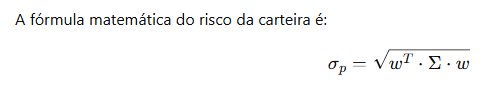

##### Fórmula do retorno médio é simplesmente a média anual de cada benchmark

---



In [6]:
def portfolio_risk(weights, returns):
    cov_matrix = returns.cov()
    return np.sqrt(weights.T @ cov_matrix @ weights)

def portfolio_return(weights, returns):
    """
    Calcula o retorno esperado anual da carteira

    weights: array-like (soma = 1)
    returns: DataFrame com retornos históricos (anos x ativos)
    """
    mean_returns = returns.mean()   # Retorno médio anual de cada ativo
    return np.dot(weights, mean_returns)


In [7]:
N_ASSETS = returns.shape[1]

def generate_individual():
    weights = np.random.rand(N_ASSETS)
    weights /= weights.sum()   # Normaliza para Somar 1
    return weights.tolist()


In [8]:
# DEAP maximiza tudo → risco entra negativo

creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0)) #1 é Maximixar e -1 minimizar::
creator.create("Individual", list, fitness=creator.FitnessMulti)


### Evaluate com Penalização de máximo de 30% e minimo de 3% com objetivo de diversificar


In [9]:
def evaluate(individual):
    weights = np.array(individual)

    # garante não-negatividade
    weights = np.maximum(weights, 0)

    # normaliza soma = 1
    weights = weights / weights.sum()

    ret = portfolio_return(weights, returns)
    risk = portfolio_risk(weights, returns)


    # limites
    min_w = 0.03 #Minimo de 3% para fins de diversificação
    max_w = 0.30 # Máximo de 30%

    # excesso acima do máximo
    excess = np.maximum(0, weights - max_w)

    # falta abaixo do mínimo
    shortage = np.maximum(0, min_w - weights)

    penalty = np.sum(excess**2) + np.sum(shortage**2)

    PENALTY_FACTOR = 1000 # Verirficar se é um fator pequeno

    return (
        ret - PENALTY_FACTOR * penalty,
        risk + PENALTY_FACTOR * penalty
    )

# Toolbox (Registro de funções)

In [10]:
toolbox = base.Toolbox()

toolbox.register("evaluate", evaluate)


toolbox.register(
    "individual",
    tools.initIterate,
    creator.Individual,
    generate_individual
)

toolbox.register(
    "population",
    tools.initRepeat,
    list,
    toolbox.individual
)



# Operadores Genéticos

In [11]:
toolbox.register("mate", tools.cxSimulatedBinaryBounded,
                 low=0.0, up=1.0, eta=20.0)# cruzamento

toolbox.register("mutate", tools.mutPolynomialBounded, # mutação
                 low=0.0, up=1.0, eta=20.0, indpb=0.1)

toolbox.register("select", tools.selNSGA2) #seleção



### Rodando o algoritmo

In [12]:
POP_SIZE = 200
N_GEN = 400
CXPB = 0.9
MUTPB = 0.1

population = toolbox.population(n=POP_SIZE)

# Avalia população inicial
fitnesses = list(map(toolbox.evaluate, population))
for ind, fit in zip(population, fitnesses):
    ind.fitness.values = fit

# NSGA-II precisa dessa linha
population = toolbox.select(population, len(population))


In [13]:
for gen in range(1, N_GEN + 1):

    offspring = algorithms.varAnd(
        population,
        toolbox,
        cxpb=CXPB,
        mutpb=MUTPB
    )

    fitnesses = map(toolbox.evaluate, offspring)
    for ind, fit in zip(offspring, fitnesses):
        ind.fitness.values = fit

    population = toolbox.select(
        population + offspring,
        POP_SIZE
    )


# Resultado

In [14]:
pareto_front = tools.sortNondominated(
    population,
    k=len(population),
    first_front_only=True
)[0]


In [15]:
returns_pf = [ind.fitness.values[0] for ind in pareto_front]
risks_pf = [ind.fitness.values[1] for ind in pareto_front]
weights_pf = [np.array(ind) / np.sum(ind) for ind in pareto_front]


# Gráfico

In [16]:
import plotly.express as px



df = pd.DataFrame({
    "Risco": risks_pf,
    "Retorno": returns_pf
})

fig = px.scatter(
    df,
    x="Risco",
    y="Retorno",
    title="Fronteira Eficiente - NSGA-II"
)

fig.show()


# Portfólio com o menor Risco (Variância)

In [17]:
# menor risco

risks_pf = np.array(risks_pf)

idx_min_risk = risks_pf.argmin()

min_var_weights = weights_pf[idx_min_risk] # Fator de pesos de investimento
min_var_risk = risks_pf[idx_min_risk]
min_var_return = returns_pf[idx_min_risk]



In [18]:
min_var_weights

min_var_portfolio = pd.Series(
    min_var_weights,
    index=returns.columns,
    name="Peso"
)

print("Retorno Esperado")
print(min_var_return)


print("------------")


print("Volatilidade")
print(min_var_risk)

print("------------")


print("Portfólio com menor variância")
min_var_portfolio


Retorno Esperado
0.10895045890834357
------------
Volatilidade
0.028868452169479388
------------
Portfólio com menor variância


benchmark
CDI                         0.192737
Dólar                       0.116892
IDA-DI                      0.296323
IFIX                        0.030049
IHFA                        0.071860
IMA-B                       0.030568
IMA-B 5+                    0.032699
IRF-M                       0.030904
Ibovespa                    0.029961
Ouro - XAU                  0.030463
S&P 500 (Moeda Original)    0.137543
Name: Peso, dtype: float64

# Calculando retorno dessa carteira

In [19]:
# retorno anual da carteira (produto matricial ano x ativos)

portfolio_returns = returns.dot(min_var_portfolio)

portfolio_returns.name = "Retorno Carteira"

portfolio_cum_return = (1 + portfolio_returns).cumprod() - 1
portfolio_cum_return.name = "Retorno Acumulado"

portfolio_perf = pd.DataFrame({
    "Retorno Anual": portfolio_returns,
    "Retorno Acumulado": portfolio_cum_return
})


#puxando cdi
portfolio_perf = portfolio_perf.reset_index()
portfolio_perf = pd.merge(portfolio_perf, df_cdi[['Ano','rentabilidade']], how='left', on='Ano')
portfolio_perf = portfolio_perf.rename(columns={"rentabilidade": "rentabilidade_cdi"})
portfolio_perf['%cdi'] = portfolio_perf['Retorno Anual']/portfolio_perf['rentabilidade_cdi']
portfolio_perf["cdi_acumulado"] = (1 + portfolio_perf["rentabilidade_cdi"]).cumprod() - 1
portfolio_perf['%cdi_acumulado'] = portfolio_perf['Retorno Acumulado']/portfolio_perf['cdi_acumulado']

portfolio_perf


,Ano,Retorno Anual,Retorno Acumulado,rentabilidade_cdi,%cdi,cdi_acumulado,%cdi_acumulado
0,2011,0.104919,0.104919,0.115943,0.904915,0.115943,0.904915
1,2012,0.125678,0.243782,0.084132,1.493809,0.209830,1.161808
2,2013,0.084649,0.349068,0.080532,1.051122,0.307261,1.136064
3,2014,0.108805,0.495853,0.108069,1.006811,0.448535,1.105495
4,2015,0.147438,0.716399,0.132290,1.114509,0.640161,1.119091
5,2016,0.122569,0.926775,0.140012,0.875416,0.869803,1.065500
6,2017,0.121706,1.161276,0.099522,1.222914,1.055889,1.099809
7,2018,0.074106,1.321439,0.064233,1.153706,1.187945,1.112375
8,2019,0.128509,1.619765,0.059679,2.153349,1.318518,1.228474
9,2020,0.093847,1.865621,0.027677,3.390782,1.382688,1.349271


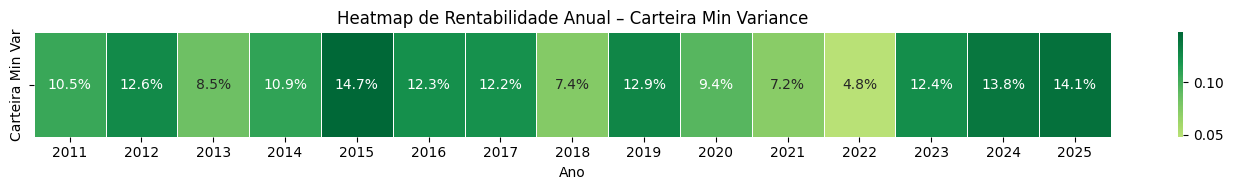

In [20]:

heatmap_data = portfolio_returns.to_frame().T
heatmap_data.index = ["Carteira Min Var"]

plt.figure(figsize=(14, 2))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1%",
    linewidths=0.5,
    cbar=True
)

plt.title("Heatmap de Rentabilidade Anual – Carteira Min Variance")
plt.xlabel("Ano")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [21]:
best_portfolio_sorted = min_var_portfolio.sort_values(ascending=False) * 100

df_plot = best_portfolio_sorted.reset_index()
df_plot.columns = ["Classe", "Percentual"]

# Criar gráfico
fig = px.bar(
    df_plot,
    x="Percentual",
    y="Classe",
    orientation="h",
    text=df_plot["Percentual"].map(lambda x: f"{x:.2f}%"),
)

# Ajustar layout
fig.update_layout(
    title="Alocação Ótima por Classe",
    xaxis_title="Percentual (%)",
    yaxis_title="",
    yaxis=dict(autorange="reversed"),  # maior no topo
)

fig.update_traces(textposition="outside")

fig.show()

# Carteira de maior retorno (maior volatilidade)




In [22]:
returns_pf = np.array(returns_pf)

idx_max_return = returns_pf.argmax()

max_ret_weights = weights_pf[idx_max_return] #fator de pesos de investimento
max_ret_risk = risks_pf[idx_max_return]
max_ret_return = returns_pf[idx_max_return]

In [23]:
max_ret_weights

max_ret_portfolio = pd.Series(
    max_ret_weights,
    index=returns.columns,
    name="Peso"
)


print("Retorno Esperado")
print(max_ret_return)


print("------------")


print("Volatilidade")
print(max_ret_risk)

print("------------")


print("Portfólio com maior retorno")


max_ret_portfolio

Retorno Esperado
0.1342442755701398
------------
Volatilidade
0.0782070333206371
------------
Portfólio com maior retorno


benchmark
CDI                         0.031628
Dólar                       0.030636
IDA-DI                      0.229453
IFIX                        0.031091
IHFA                        0.050334
IMA-B                       0.031502
IMA-B 5+                    0.033896
IRF-M                       0.042310
Ibovespa                    0.030579
Ouro - XAU                  0.300099
S&P 500 (Moeda Original)    0.188473
Name: Peso, dtype: float64

# Calculando retorno dessa carteira

In [24]:
portfolio_returns = returns.dot(max_ret_portfolio)

portfolio_returns.name = "Retorno Carteira"

portfolio_cum_return = (1 + portfolio_returns).cumprod() - 1
portfolio_cum_return.name = "Retorno Acumulado"

portfolio_perf = pd.DataFrame({
    "Retorno Anual": portfolio_returns,
    "Retorno Acumulado": portfolio_cum_return
})



#puxando cdi
portfolio_perf = portfolio_perf.reset_index()
portfolio_perf = pd.merge(portfolio_perf, df_cdi[['Ano','rentabilidade']], how='left', on='Ano')
portfolio_perf = portfolio_perf.rename(columns={"rentabilidade": "rentabilidade_cdi"})
portfolio_perf['%cdi'] = portfolio_perf['Retorno Anual']/portfolio_perf['rentabilidade_cdi']
portfolio_perf["cdi_acumulado"] = (1 + portfolio_perf["rentabilidade_cdi"]).cumprod() - 1
portfolio_perf['%cdi_acumulado'] = portfolio_perf['Retorno Acumulado']/portfolio_perf['cdi_acumulado']


portfolio_perf

,Ano,Retorno Anual,Retorno Acumulado,rentabilidade_cdi,%cdi,cdi_acumulado,%cdi_acumulado
0,2011,0.134072,0.134072,0.115943,1.156361,0.115943,1.156361
1,2012,0.145156,0.298690,0.084132,1.725328,0.209830,1.423482
2,2013,0.019532,0.324056,0.080532,0.242541,0.307261,1.054661
3,2014,0.112866,0.473496,0.108069,1.044387,0.448535,1.055651
4,2015,0.154193,0.700699,0.132290,1.165570,0.640161,1.094567
5,2016,0.085846,0.846697,0.140012,0.613134,0.869803,0.973435
6,2017,0.143607,1.111896,0.099522,1.442974,1.055889,1.053043
7,2018,0.083043,1.287275,0.064233,1.292846,1.187945,1.083615
8,2019,0.189237,1.720112,0.059679,3.170937,1.318518,1.304580
9,2020,0.233742,2.355917,0.027677,8.445360,1.382688,1.703868


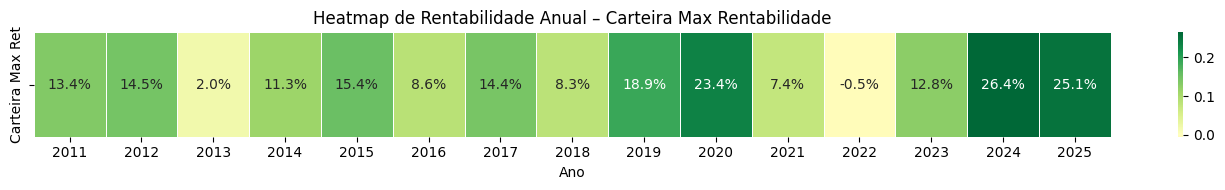

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 


heatmap_data = portfolio_returns.to_frame().T
heatmap_data.index = ["Carteira Max Ret"]

plt.figure(figsize=(14, 2))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1%",
    linewidths=0.5,
    cbar=True
)

plt.title("Heatmap de Rentabilidade Anual – Carteira Max Rentabilidade")
plt.xlabel("Ano")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [26]:
best_portfolio_sorted = max_ret_portfolio.sort_values(ascending=False) * 100

df_plot = best_portfolio_sorted.reset_index()
df_plot.columns = ["Classe", "Percentual"]

# Criar gráfico
fig = px.bar(
    df_plot,
    x="Percentual",
    y="Classe",
    orientation="h",
    text=df_plot["Percentual"].map(lambda x: f"{x:.2f}%"),
)

# Ajustar layout
fig.update_layout(
    title="Alocação Ótima por Classe",
    xaxis_title="Percentual (%)",
    yaxis_title="",
    yaxis=dict(autorange="reversed"),  # maior no topo
)

fig.update_traces(textposition="outside")

fig.show()

# Carteira melhor relação risco retorno (Sharpe)*

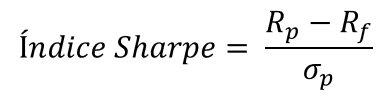

In [27]:
# carteira de melhor sharpe

risks_array = np.array(risks_pf)
returns_array = np.array(returns_pf)

#sharpe = returns_array / risks_array

rf = 0.10  # Exemplo de 10% minimo de entrega

sharpe = (returns_array - rf) / risks_array


idx_best_sharpe = sharpe.argmax() #Encontrar a carteira com o maior sharpe, ou seja melhor relação risco retorno

best_weights = weights_pf[idx_best_sharpe]

In [31]:
best_portfolio = pd.Series(
    best_weights,
    index=returns.columns,
    name="Peso"
)

best_return = returns_array[idx_best_sharpe]
best_risk = risks_array[idx_best_sharpe]

print("Retorno esperado:", best_return)
print("Risco (volatilidade):", best_risk)
print("Sharpe:", sharpe[idx_best_sharpe])

best_portfolio

Retorno esperado: 0.12376610369485651
Risco (volatilidade): 0.05150627840656776
Sharpe: 0.46142148938149635


benchmark
CDI                         0.032340
Dólar                       0.030306
IDA-DI                      0.299941
IFIX                        0.030282
IHFA                        0.126671
IMA-B                       0.031210
IMA-B 5+                    0.032771
IRF-M                       0.033626
Ibovespa                    0.030269
Ouro - XAU                  0.172024
S&P 500 (Moeda Original)    0.180561
Name: Peso, dtype: float64

In [32]:
portfolio_returns = returns.dot(best_portfolio)

portfolio_returns.name = "Retorno Carteira"

portfolio_cum_return = (1 + portfolio_returns).cumprod() - 1
portfolio_cum_return.name = "Retorno Acumulado"

portfolio_perf = pd.DataFrame({
    "Retorno Anual": portfolio_returns,
    "Retorno Acumulado": portfolio_cum_return
})

#puxando cdi
portfolio_perf = portfolio_perf.reset_index()
portfolio_perf = pd.merge(portfolio_perf, df_cdi[['Ano','rentabilidade']], how='left', on='Ano')
portfolio_perf = portfolio_perf.rename(columns={"rentabilidade": "rentabilidade_cdi"})
portfolio_perf['%cdi'] = portfolio_perf['Retorno Anual']/portfolio_perf['rentabilidade_cdi']
portfolio_perf["cdi_acumulado"] = (1 + portfolio_perf["rentabilidade_cdi"]).cumprod() - 1
portfolio_perf['%cdi_acumulado'] = portfolio_perf['Retorno Acumulado']/portfolio_perf['cdi_acumulado']



portfolio_perf

,Ano,Retorno Anual,Retorno Acumulado,rentabilidade_cdi,%cdi,cdi_acumulado,%cdi_acumulado
0,2011,0.118187,0.118187,0.115943,1.019348,0.115943,1.019348
1,2012,0.140836,0.275668,0.084132,1.673984,0.209830,1.313765
2,2013,0.052176,0.342227,0.080532,0.647889,0.307261,1.113799
3,2014,0.108213,0.487473,0.108069,1.001335,0.448535,1.086813
4,2015,0.138189,0.693025,0.132290,1.044592,0.640161,1.082580
5,2016,0.116641,0.890502,0.140012,0.833081,0.869803,1.023797
6,2017,0.140268,1.155680,0.099522,1.409428,1.055889,1.094509
7,2018,0.072950,1.312936,0.064233,1.135704,1.187945,1.105216
8,2019,0.167776,1.700991,0.059679,2.811325,1.318518,1.290078
9,2020,0.160161,2.133585,0.027677,5.786803,1.382688,1.543071


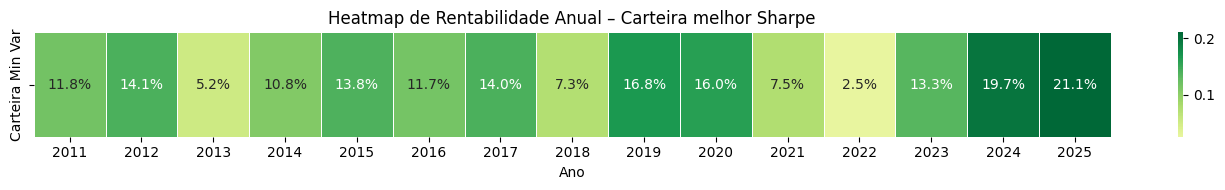

In [33]:

heatmap_data = portfolio_returns.to_frame().T
heatmap_data.index = ["Carteira Min Var"]

plt.figure(figsize=(14, 2))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".1%",
    linewidths=0.5,
    cbar=True
)

plt.title("Heatmap de Rentabilidade Anual – Carteira melhor Sharpe")
plt.xlabel("Ano")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [34]:
best_portfolio_sorted = best_portfolio.sort_values(ascending=False) * 100

df_plot = best_portfolio_sorted.reset_index()
df_plot.columns = ["Classe", "Percentual"]

# Criar gráfico
fig = px.bar(
    df_plot,
    x="Percentual",
    y="Classe",
    orientation="h",
    text=df_plot["Percentual"].map(lambda x: f"{x:.2f}%"),
)

# Ajustar layout
fig.update_layout(
    title="Alocação Ótima por Classe",
    xaxis_title="Percentual (%)",
    yaxis_title="",
    yaxis=dict(autorange="reversed"),  # maior no topo
)

fig.update_traces(textposition="outside")

fig.show()

# Fazendo Markovitz




In [35]:
import math
from IPython.display import display, Markdown
from scipy.optimize import minimize

In [39]:
## markovitz

#df = pd.read_excel("data//base_benchmarks.xlsx")
df = pd.read_excel("base_benchmarks.xlsx")


df['rentabilidade'] = pd.to_numeric(df['rentabilidade'], errors='coerce')

returns = (
    df
    .pivot(index="Ano", columns="benchmark", values="rentabilidade")
    .sort_index()
)

#Puxando retorno Esperado
retorno_esperado = retorno_esperado_function(df)
corr_matrix, cov_matrix = cov_corr(df)

mu = (
    retorno_esperado
    .set_index("benchmark")["rentabilidade"]
    .values
)

Sigma = cov_matrix.values

ativos = cov_matrix.columns.tolist()

In [40]:
#Funções Risco Retorno

def portfolio_return(weights, mu):
    return np.dot(weights, mu)


def portfolio_risk(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)

In [41]:
#funções Objetivo

def objective_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

In [42]:
#Restrições
constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1}

)

#bounds = [(0, 1) for _ in range(len(mu))]  #sem posicao short
bounds = [(0.03, 0.3) for _ in range(len(mu))]

In [43]:
#Pesos Iniciais

initial_weights = np.ones(len(mu)) / len(mu)

In [44]:
#otimização de markovitz
result = minimize(
    objective_variance,
    initial_weights,
    args=(Sigma,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [45]:
#Resultado

weights_markowitz = result.x

ret_markowitz = portfolio_return(weights_markowitz, mu)
risk_markowitz = portfolio_risk(weights_markowitz, Sigma)

resultado_markowitz = pd.DataFrame({
    "Ativo": ativos,
    "Peso_Markowitz": weights_markowitz
})

resultado_markowitz["Peso_Markowitz"] = resultado_markowitz["Peso_Markowitz"].round(4)
resultado_markowitz = resultado_markowitz[resultado_markowitz["Peso_Markowitz"] > 0]

print("Retorno esperado:", ret_markowitz)
print("---------")


print("Risco (vol):", risk_markowitz)
print("---------")


resultado_markowitz

Retorno esperado: 0.10712539621957959
---------
Risco (vol): 0.02838038343946053
---------


,Ativo,Peso_Markowitz
0,CDI,0.2286
1,Dólar,0.1219
2,IDA-DI,0.2664
3,IFIX,0.0300
4,IHFA,0.1210
5,IMA-B,0.0300
6,IMA-B 5+,0.0300
7,IRF-M,0.0300
8,Ibovespa,0.0300
9,Ouro - XAU,0.0300


In [46]:
retornos = df.pivot_table(
    index="data",
    columns="benchmark",
    values="rentabilidade",
    aggfunc="mean"
).sort_index()

retornos = retornos.fillna(0)

retornos = retornos[ativos]

retorno_carteira_t = retornos @ weights_markowitz

rentabilidade_acumulada = (1 + retorno_carteira_t).cumprod() - 1



In [47]:
print(retorno_carteira_t)
print('----')
print('Rentabilidade Acumulada')
print(rentabilidade_acumulada.iloc[-1])



data
01/01/2011 até 31/12/2011    0.110606
01/01/2012 até 31/12/2012    0.124783
01/01/2013 até 31/12/2013    0.073807
01/01/2014 até 31/12/2014    0.106401
01/01/2015 até 31/12/2015    0.158893
01/01/2016 até 31/12/2016    0.123415
01/01/2017 até 31/12/2017    0.116604
01/01/2018 até 31/12/2018    0.081343
01/01/2019 até 31/12/2019    0.117455
01/01/2020 até 31/12/2020    0.088818
01/01/2021 até 31/12/2021    0.057540
01/01/2022 até 31/12/2022    0.065417
01/01/2023 até 31/12/2023    0.114527
01/01/2024 até 31/12/2024    0.129088
01/01/2025 até 31/12/2025    0.138182
dtype: float64
----
Rentabilidade Acumulada
3.5808531395587675


In [48]:
from os import rename
# aqui plotar as duas carteiras
df_genetico  = min_var_portfolio.reset_index()
df_genetico = df_genetico.rename(columns={"benchmark": "Ativo"})
comparativo = pd.merge(df_genetico, resultado_markowitz, how='left', on='Ativo')

comparativo['Delta'] =  comparativo['Peso'] - comparativo['Peso_Markowitz']


In [49]:
comparativo

,Ativo,Peso,Peso_Markowitz,Delta
0,CDI,0.192737,0.2286,-0.035863
1,Dólar,0.116892,0.1219,-0.005008
2,IDA-DI,0.296323,0.2664,0.029923
3,IFIX,0.030049,0.0300,0.000049
4,IHFA,0.071860,0.1210,-0.049140
5,IMA-B,0.030568,0.0300,0.000568
6,IMA-B 5+,0.032699,0.0300,0.002699
7,IRF-M,0.030904,0.0300,0.000904
8,Ibovespa,0.029961,0.0300,-0.000039
9,Ouro - XAU,0.030463,0.0300,0.000463


In [50]:
print("Retorno esperado markowitz:", ret_markowitz)
print("Risco (vol) markowitz:", risk_markowitz)

print("------------")

print("Retorno Esperado genético", min_var_return)
print("Volatilidade genético", min_var_risk )

Retorno esperado markowitz: 0.10712539621957959
Risco (vol) markowitz: 0.02838038343946053
------------
Retorno Esperado genético 0.10895045890834357
Volatilidade genético 0.028868452169479388


# Comparação Final

In [53]:
resumo = pd.DataFrame({
    "Carteira": [
        "Min Variância (AG)", 
        "Melhor Sharpe (AG)", 
        "Maior Retorno (AG)", 
        "Markowitz"
    ],
    "Retorno Esperado": [
        min_var_return, 
        returns_array[idx_best_sharpe],
        max_ret_return, 
        ret_markowitz
    ],
    "Volatilidade": [
        min_var_risk, 
        risks_array[idx_best_sharpe],
        max_ret_risk, 
        risk_markowitz
    ],
    "Sharpe (rf=10%)": [
        (min_var_return - 0.10) / min_var_risk,
        sharpe[idx_best_sharpe],
        (max_ret_return - 0.10) / max_ret_risk,
        (ret_markowitz - 0.10) / risk_markowitz
    ],
    "Retorno Acumulado": [3.698, 4.739, 5.471, 3.581]
}).round(4)

resumo.style.highlight_max(
    subset=["Retorno Esperado", "Sharpe (rf=10%)", "Retorno Acumulado"],
    color="lightgreen"
).highlight_min(
    subset=["Volatilidade"],
    color="lightgreen"
)

,Carteira,Retorno Esperado,Volatilidade,Sharpe (rf=10%),Retorno Acumulado
0,Min Variância (AG),0.109000,0.028900,0.310000,3.698000
1,Melhor Sharpe (AG),0.123800,0.051500,0.461400,4.739000
2,Maior Retorno (AG),0.134200,0.078200,0.437900,5.471000
3,Markowitz,0.107100,0.028400,0.251100,3.581000
